In [422]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Garbage Collector
import gc 

import pandas as pd
import numpy as np
import os

# Time Modules
import calendar
import time
import datetime
from datetime import datetime, timedelta

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


# Plots 983.369+

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.graph_objects as go
import plotly.express as px
import plotly.subplots as sp
sns.set_style("whitegrid")
sns.set(rc={'figure.figsize':(18, 12)})
%matplotlib inline

# Statistics 
from scipy.stats import norm
from scipy.stats import zscore
from scipy import stats

import warnings
warnings.filterwarnings('ignore')
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [423]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
occupancy_detection = fetch_ucirepo(id=357) 
  
# data (as pandas dataframes) 
X = occupancy_detection.data.features 
y = occupancy_detection.data.targets 
  
# metadata 
print(occupancy_detection.metadata) 
  
# variable information 
print(occupancy_detection.variables) 

{'uci_id': 357, 'name': 'Occupancy Detection ', 'repository_url': 'https://archive.ics.uci.edu/dataset/357/occupancy+detection', 'data_url': 'https://archive.ics.uci.edu/static/public/357/data.csv', 'abstract': 'Experimental data used for binary classification (room occupancy) from Temperature,Humidity,Light and CO2. Ground-truth occupancy was obtained from time stamped pictures that were taken every minute.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 20560, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Occupancy'], 'index_col': ['id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2016, 'last_updated': 'Sat Apr 13 2024', 'dataset_doi': '10.24432/C5X01N', 'creators': ['Luis Candanedo'], 'intro_paper': {'ID': 470, 'type': 'NATIVE', 'title': 'Accurate occupancy detection of an office room from light, temperature, humidity and CO2

In [424]:
y.value_counts(ascending=False, normalize=True)

Occupancy
0.0          0.768969
1.0          0.231031
Name: proportion, dtype: float64

In [425]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20562 entries, 0 to 20561
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           20562 non-null  object
 1   Temperature    20562 non-null  object
 2   Humidity       20562 non-null  object
 3   Light          20562 non-null  object
 4   CO2            20562 non-null  object
 5   HumidityRatio  20562 non-null  object
dtypes: object(6)
memory usage: 964.0+ KB


In [426]:
X.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio
0,2015-02-04 17:51:00,23.18,27.272,426,721.25,0.00479298817650529
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714,0.00478344094931065
2,2015-02-04 17:53:00,23.15,27.245,426,713.5,0.00477946352442199
3,2015-02-04 17:54:00,23.15,27.2,426,708.25,0.00477150882608175
4,2015-02-04 17:55:00,23.1,27.2,426,704.5,0.00475699293331518


In [427]:
print(f'Rows: {X.shape[0]}')
print(f'Columns: {X.shape[1]}')

print(f'Shape: {X.shape}')

Rows: 20562
Columns: 6
Shape: (20562, 6)


# 1. Which features are most predictive of occupancy?

Ideally could be Light, Co2 levels, Humidity Ratio or many others. We can analyze it using a heatmap in order to understand if there is any statistical correlation and using feature importance.

In [428]:
print(f'Columns: {X.columns}')

Columns: Index(['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio'], dtype='object')


In [429]:
print('Target: Occupancy')

Target: Occupancy


# 2. Why is light such a dominant feature?

The shape of the plot provides insight into how light influences our target variable, particularly since occupancy often correlates with artificial lighting usage. However, this relationship may introduce bias, as natural daylight during daytime hours can also contribute to light intensity.

Light levels appear to be highest between 09:00 and 18:00. To better understand these patterns, it is helpful to extract the day from the date column and plot light intensity for each day individually. This allows for clearer visualization of daily variations in lighting behavior.

Several anomalies are present in the data. For instance, Day 4 contains negative light values, which are likely due to sensor inaccuracies, as light measurements should not be negative. Day 2 shows unusually high light intensity between 14:00 and midnight, while Day 18 records a brief period of intense light between 08:15 and 09:30.

# Curious Insight. 

The dataset also contains some inconsistencies, particularly in columns with the object data type, which require closer inspection. It is important to always examine your data before applying any transformations or functions. In this case, some columns included string values in rows where numerical data was expected, which caused errors when attempting to use astype()

In [431]:
import re

for element in X['Humidity'].unique():
    if re.search('[a-zA-Z]', element):
        X['Humidity'] = X['Humidity'].replace(element, X['Humidity'].mode()[0])
        print(element)

for element in X['Temperature'].unique():
    if re.search('[a-zA-Z]', element):
        X['Temperature'] = X['Temperature'].replace(element, X['Temperature'].mode()[0])
        print(element)

for element in X['Light'].unique():
    if re.search('[a-zA-Z]', element):
        X['Light'] = X['Light'].replace(element, X['Light'].mode()[0])
        print(element)
        
for element in X['CO2'].unique():
    if re.search('[a-zA-Z]', element):
        X['CO2'] = X['CO2'].replace(element, X['CO2'].mode()[0])
        print(element)

for element in X['HumidityRatio'].unique():
    if re.search('[a-zA-Z]', element):
        X['HumidityRatio'] = X['HumidityRatio'].replace(element, X['HumidityRatio'].mode()[0])


"""Inconsistent values founded."""

Light
Humidity
CO2
HumidityRatio


In [432]:
X['Temperature'] = pd.to_numeric(X['Temperature'])
X['Light'] = pd.to_numeric(X['Light'])
X['CO2'] = pd.to_numeric(X['CO2'])
X['Humidity'] = pd.to_numeric(X['Humidity'])
X['HumidityRatio'] = pd.to_numeric(X['HumidityRatio'])

In [433]:
y.shape

(20562, 1)

In [434]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20562 entries, 0 to 20561
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           20562 non-null  object 
 1   Temperature    20562 non-null  float64
 2   Humidity       20562 non-null  float64
 3   Light          20562 non-null  float64
 4   CO2            20562 non-null  float64
 5   HumidityRatio  20562 non-null  float64
dtypes: float64(5), object(1)
memory usage: 964.0+ KB


In [435]:
# Remove invalid rows
X = X[X['date'].notna()]
X = X[X['date'] != 0]

# Convert safely
X['date'] = pd.to_datetime(X['date'], errors='coerce')

# Drop anything still invalid
X = X.dropna(subset=['date'])


# Models do not operate well when date time are on, I retrieve the day, the hour and what week of the day
X['Day'] = X['date'].dt.day
X['WeekDay'] = X['date'].dt.weekday
X['Hour'] = X['date'].dt.hour

# 3. How a Cyclical Encoding can improve our model accuracy?

Time variables such as hour, day of week, and month are inherently cyclical, but models interpret them as ordinary numerical values by default. Without accounting for this cyclical nature, the model may treat these features as linear integers, leading to misleading relationships (e.g., considering 23 and 0 as far apart). To address this, sine and cosine transformations are applied to encode the cyclical patterns correctly. This allows the model to capture temporal relationships more effectively and ultimately improves predictive accuracy.

In [436]:
# mapping time onto a circle instead of a line—so the model “sees” time correctly.

X['hour_sin'] = np.sin(2 * np.pi * X['Hour'] / 24)
X['hour_cos'] = np.cos(2 * np.pi * X['Hour'] / 24)

X['dow_sin'] = np.sin(2 * np.pi * X['WeekDay'] / 7)
X['dow_cos'] = np.cos(2 * np.pi * X['WeekDay'] / 7)

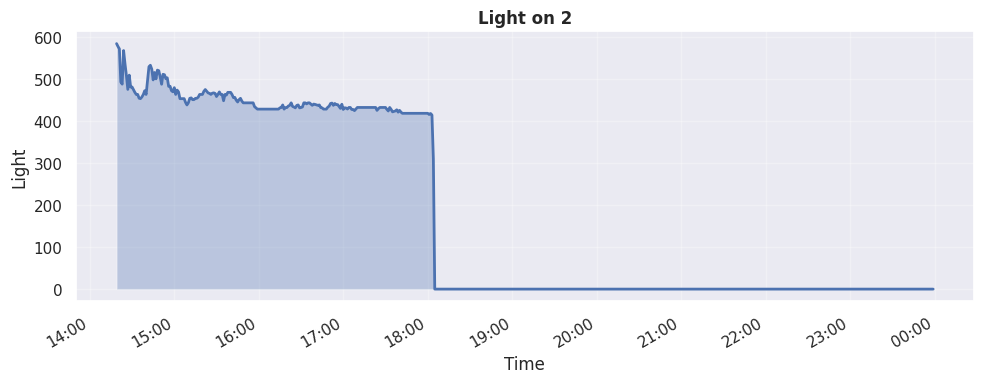

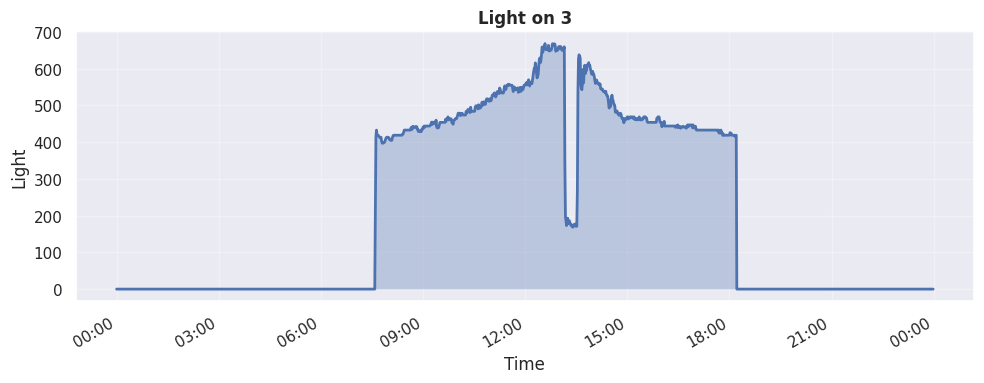

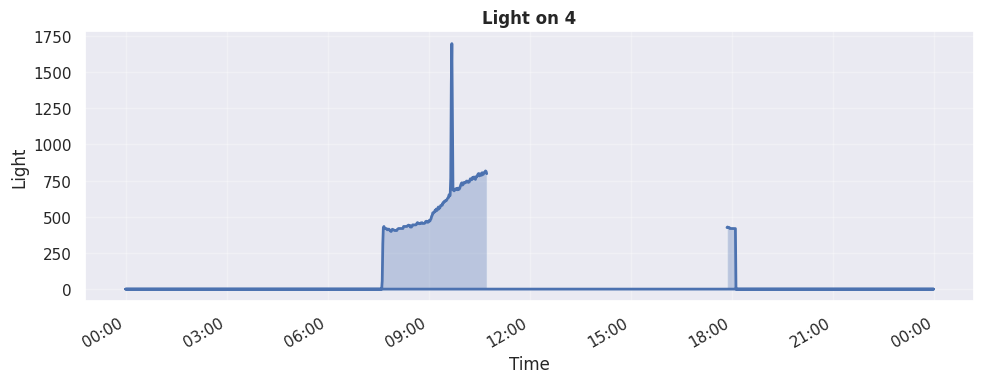

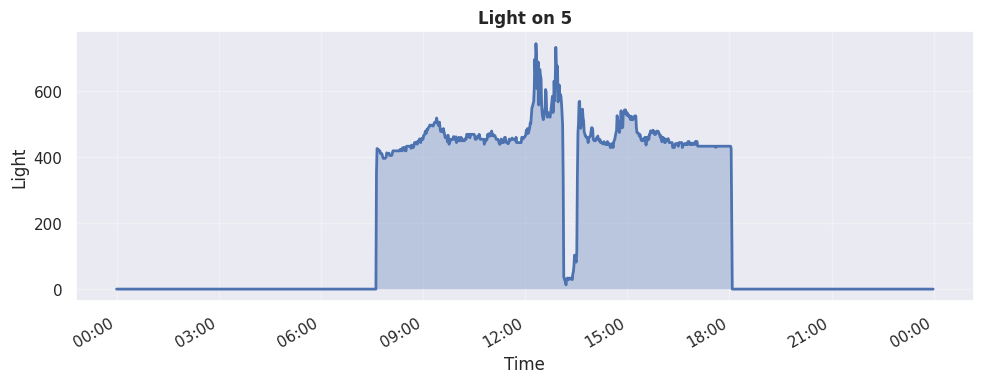

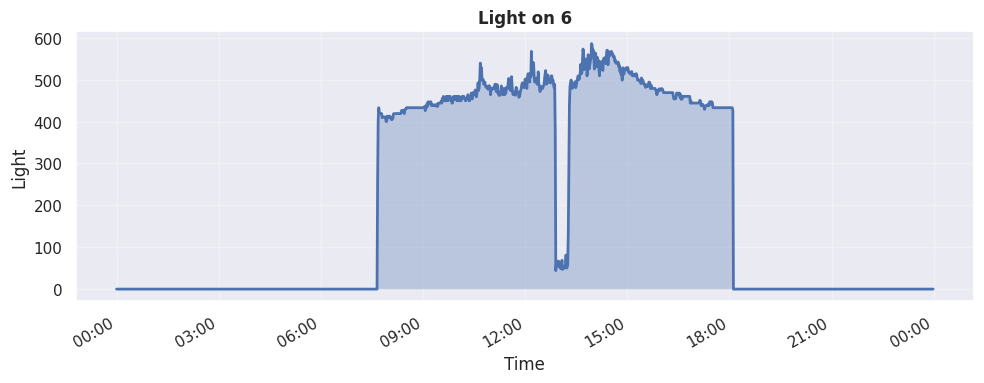

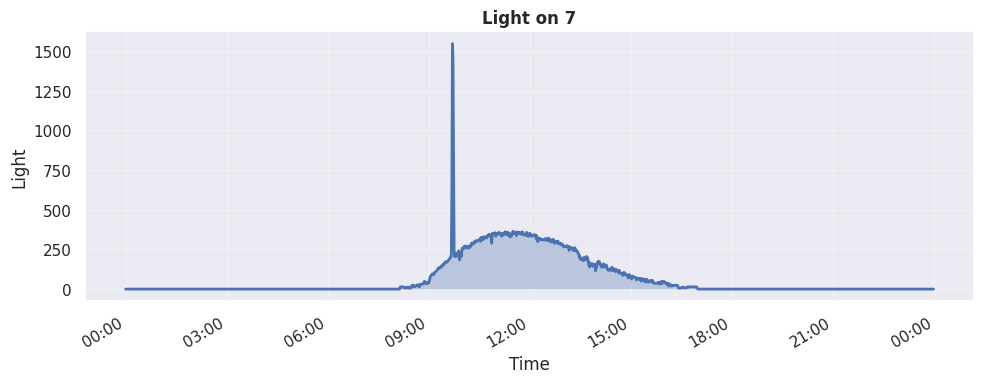

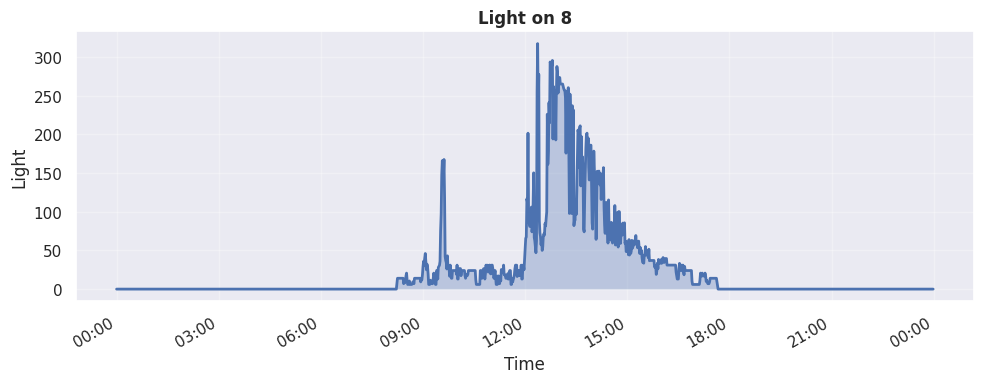

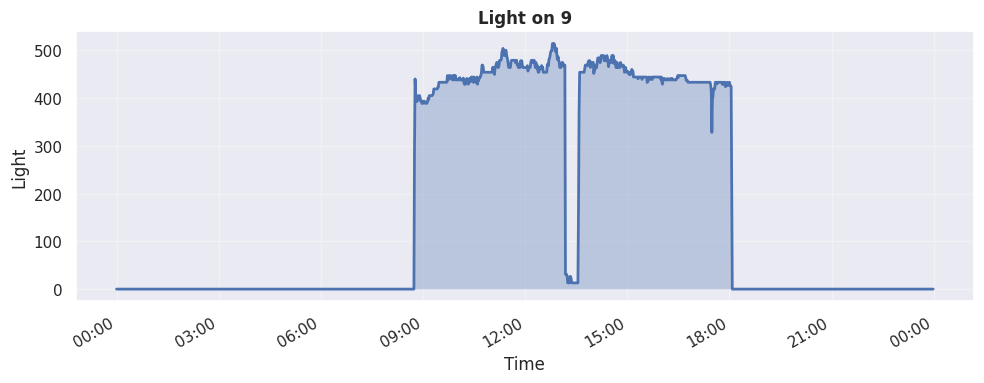

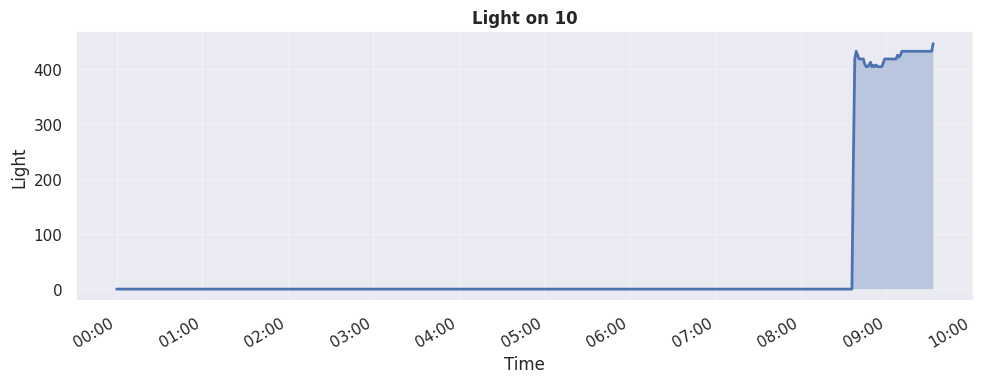

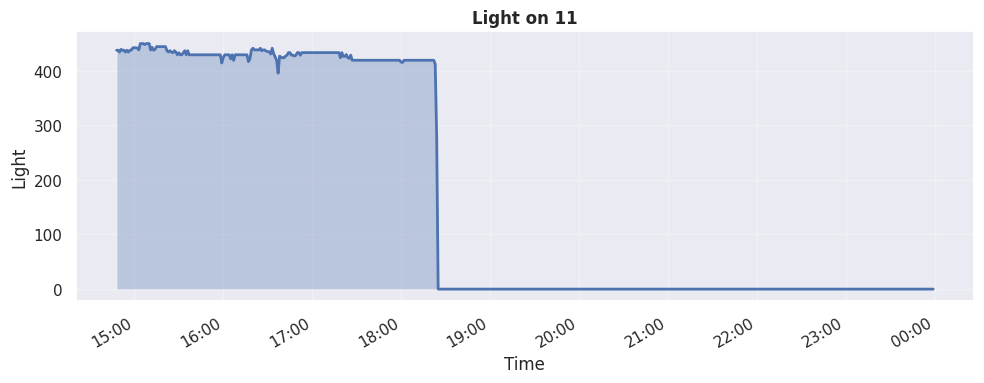

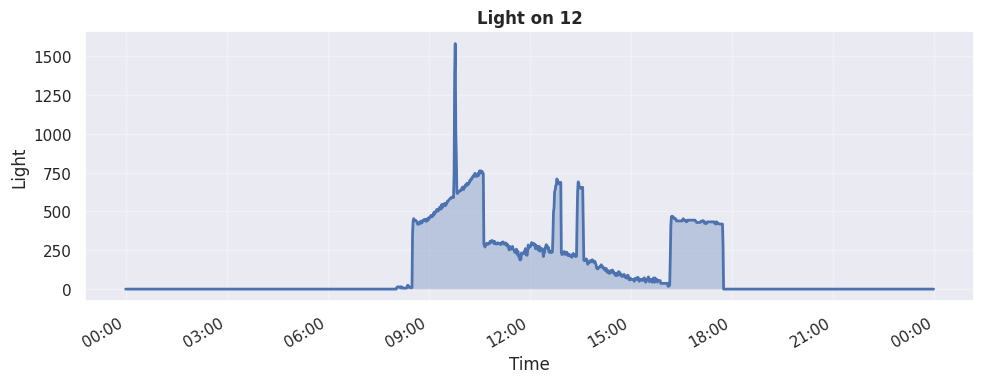

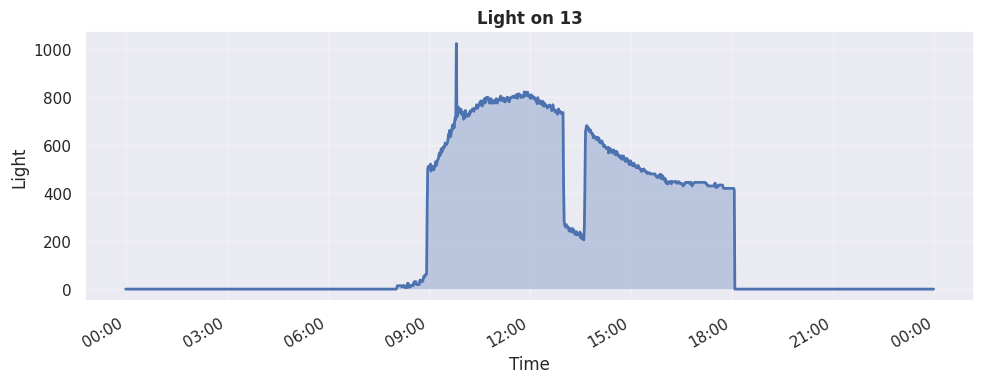

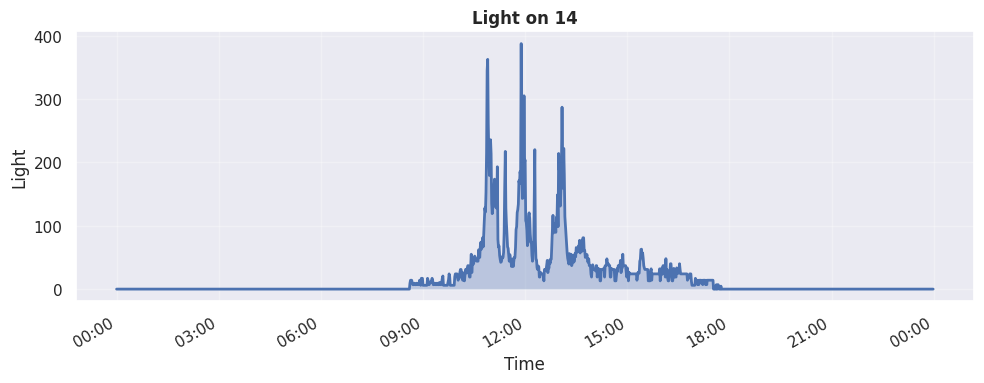

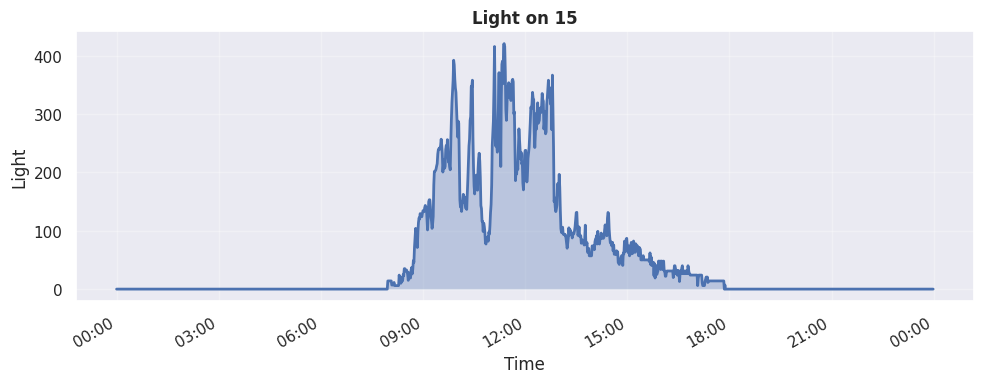

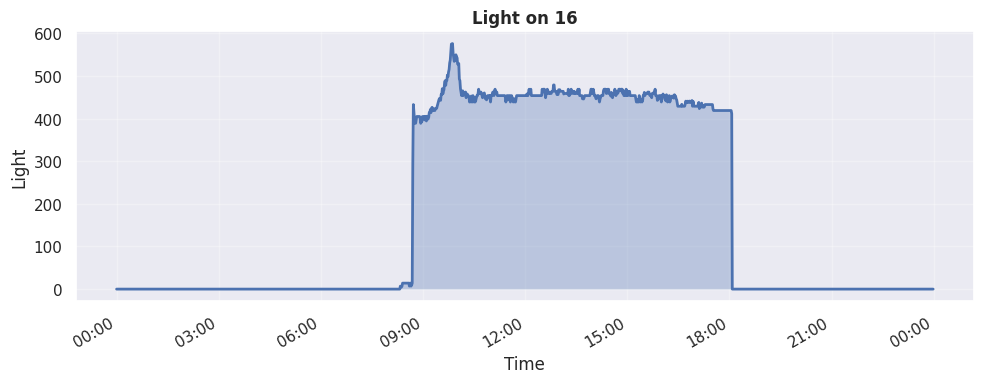

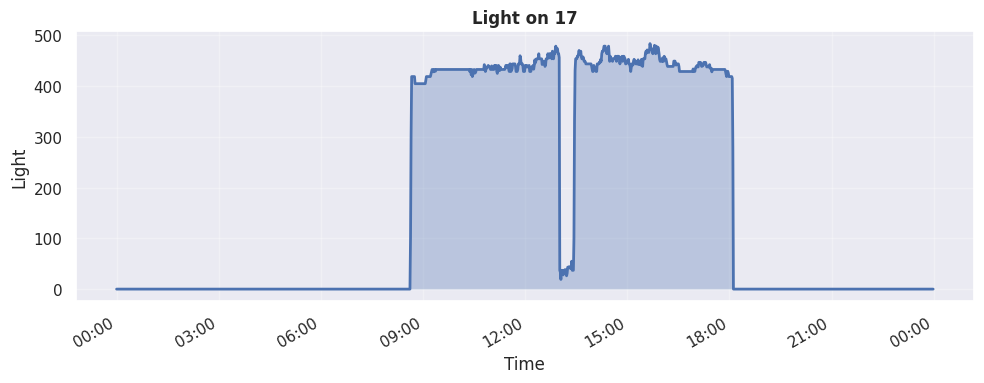

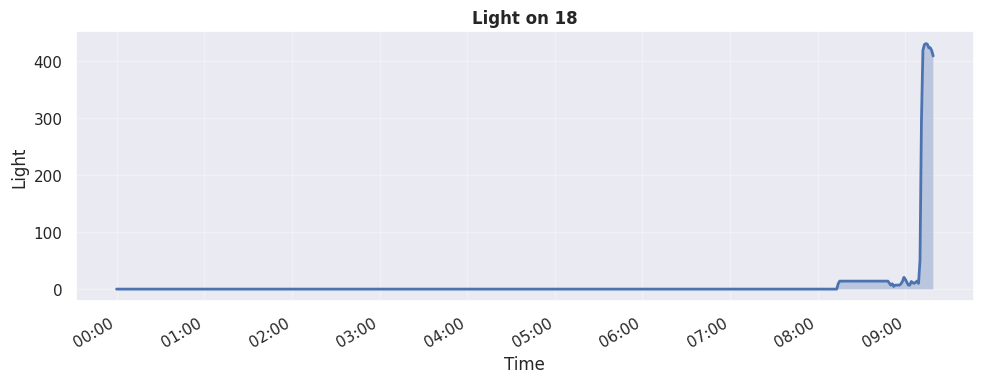

In [437]:
import matplotlib.dates as mdates

def plot_light_by_day(df):
    # Ensure datetime
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])


    # Loop through each day
    for day, group in df.groupby('Day'):
        fig, ax = plt.subplots(figsize=(10, 4))

        # Plot
        ax.fill_between(group['date'], group['Light'], alpha=0.3)
        ax.plot(group['date'], group['Light'], linewidth=2)

        # Format x-axis (time only)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        fig.autofmt_xdate()

        # Titles & labels
        ax.set_title(f'Light on {day}', fontweight='bold')
        ax.set_xlabel('Time')
        ax.set_ylabel('Light')

        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

if __name__ == '__main__':
    plot_light_by_day(X)
    plt.savefig(f'daily_light_plot.png')
    plt.close()

# 4. How would you check for multicollinearity?

I'd go for VIF, which is a tool used in regression to check if the input variables are too closely related to each other. When variables are highly correlated, it becomes harder for the model to figure out how much each one individually affects the outcome.

In simple terms, VIF measures how much this overlap between variables is making the model’s estimates less reliable. Because of this, we calculate a VIF score for each variable to see which ones might be causing problems.

I started with a correlation plot first how 'Temperature', 'Humidity','Light', 'CO2', 'HumidityRatio' variables are correlated to each other.

Since all your variables have a VIF around 7.75, this indicates high multicollinearity. It means these features are strongly correlated with each other, and they are likely providing overlapping information to the model.

The fact that all VIFs are identical is also a strong signal that the variables are highly interdependent—possibly derived from each other or moving together in the dataset. For example, something like Humidity and HumidityRatio are often closely related by definition.

#### I. Variance Inflation Factor.

In [438]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

y = y.dropna()

# Manual VIF Calculation
vif_manual = {}

for feature in ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']:
    
    # Fit the linear regression model
    model = LinearRegression().fit(X[['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']], y)

    # Calculate R-squared
    r_squared = model.score(X[['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']], y)

    # Calculate VIF
    vif = 1 / (1 - r_squared)
    vif_manual[feature] = vif

# Convert the dictionary to a DataFrame for better display
vif_manual_df = pd.DataFrame(list(vif_manual.items()), columns=['Feature', 'VIF'])
print(vif_manual_df)

         Feature       VIF
0    Temperature  7.753695
1       Humidity  7.753695
2          Light  7.753695
3            CO2  7.753695
4  HumidityRatio  7.753695


#### II. Correlation Matrix.

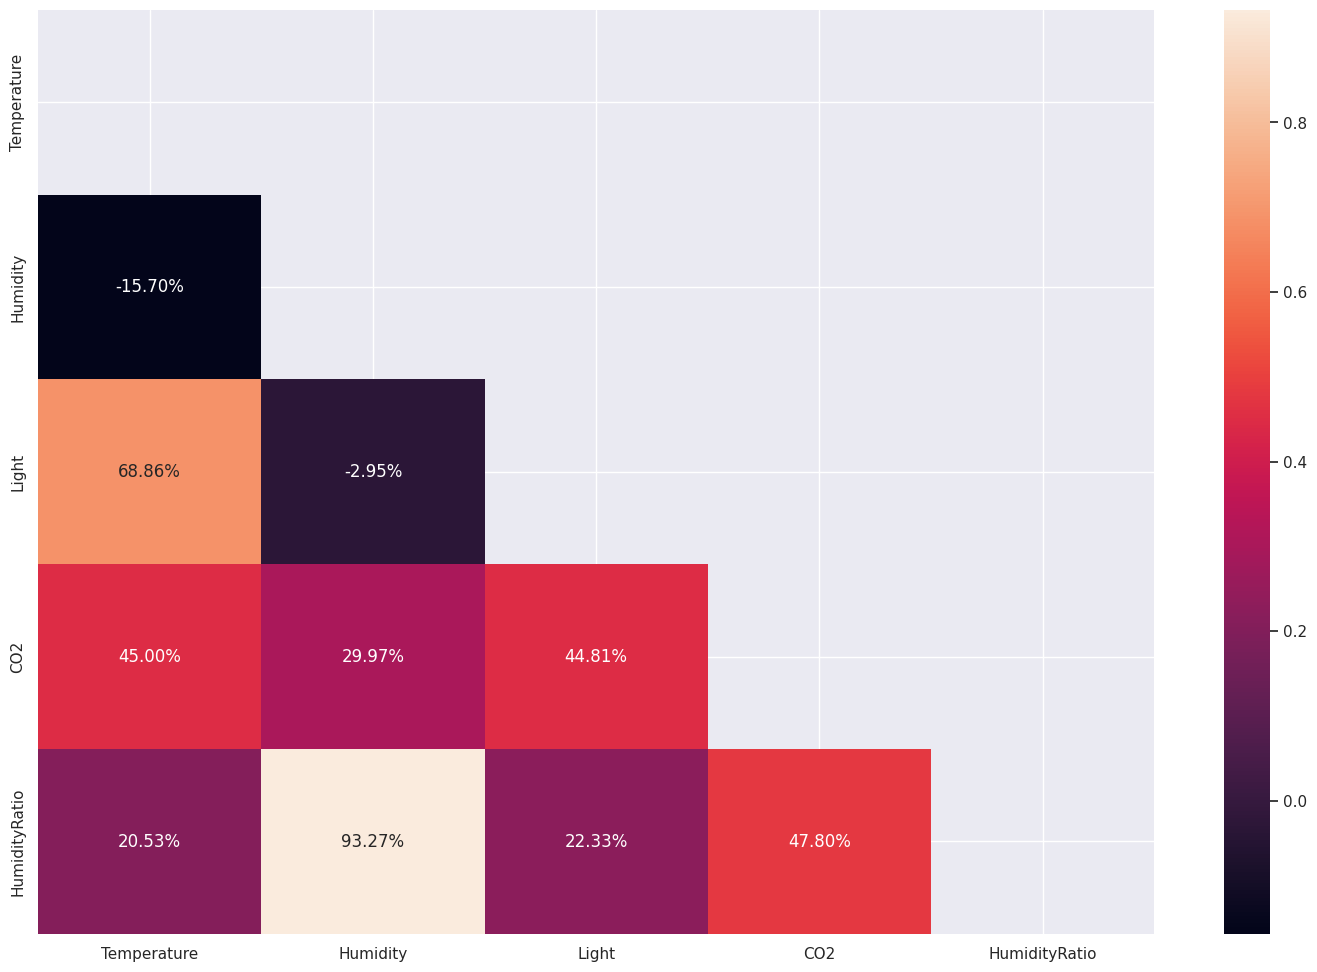

In [439]:
corr = X[['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']].corr()

# If passed, data will not be shown in cells where mask is True. Cells with missing values are automatically masked.
mask = np.triu(corr)

ax = sns.heatmap(corr, 
                 annot=True,
                 mask=mask,
                 fmt=".2%")

#### III. Humidity & Humidity Ratio.

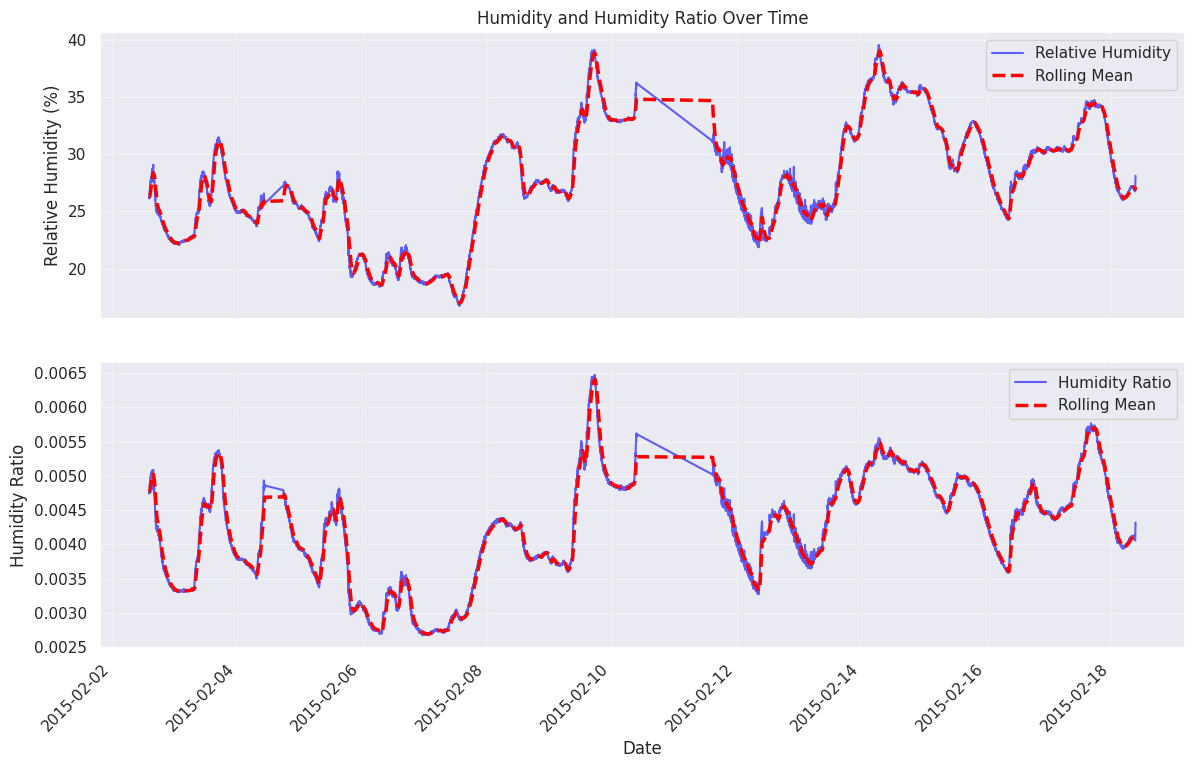

In [440]:
import matplotlib.dates as mdates


X = X.sort_values('date')

# Smoothing with Exponential Weighted Mean.
window = 60 # Data has been recorded in minute so I'd more easy to analyze it if the average is based on 60 rows.
X['humidity_smooth'] = X['Humidity'].ewm(span=window, adjust=False).mean()
X['humidity_ratio_smooth'] = X['HumidityRatio'].ewm(span=window, adjust=False).mean()

fig, axes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'hspace': 0.15}
)

# --- Humidity ---
axes[0].plot(X['date'], X['Humidity'], linewidth=1.5, alpha=0.6, label='Relative Humidity', color='blue')
axes[0].plot(X['date'], X['humidity_smooth'], linewidth=2.5, linestyle='--', label='Rolling Mean', color='red')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Humidity and Humidity Ratio Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Humidity Ratio ---
axes[1].plot(X['date'], X['HumidityRatio'], linewidth=1.5, alpha=0.6, label='Humidity Ratio', color='blue')
axes[1].plot(X['date'], X['humidity_ratio_smooth'], linewidth=2.5, linestyle='--', label='Rolling Mean', color='red')
axes[1].set_ylabel('Humidity Ratio')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Format dates
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


# fill or NaN values after rolling() with 0
X = X.fillna(0)

In [442]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20560 entries, 8144 to 20561
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   20560 non-null  datetime64[ns]
 1   Temperature            20560 non-null  float64       
 2   Humidity               20560 non-null  float64       
 3   Light                  20560 non-null  float64       
 4   CO2                    20560 non-null  float64       
 5   HumidityRatio          20560 non-null  float64       
 6   Day                    20560 non-null  int32         
 7   WeekDay                20560 non-null  int32         
 8   Hour                   20560 non-null  int32         
 9   hour_sin               20560 non-null  float64       
 10  hour_cos               20560 non-null  float64       
 11  dow_sin                20560 non-null  float64       
 12  dow_cos                20560 non-null  float64       
 13  hum

# 5. Is the dataset balanced?

The dataset exhibits a significant class imbalance, with 76.9% of instances labeled as occupied and 23.1% as non-occupied. This imbalance is likely to affect model performance and bias predictions toward the majority class. To improve accuracy and robustness, techniques such as feature scaling and Principal Component Analysis (PCA) may be beneficial.

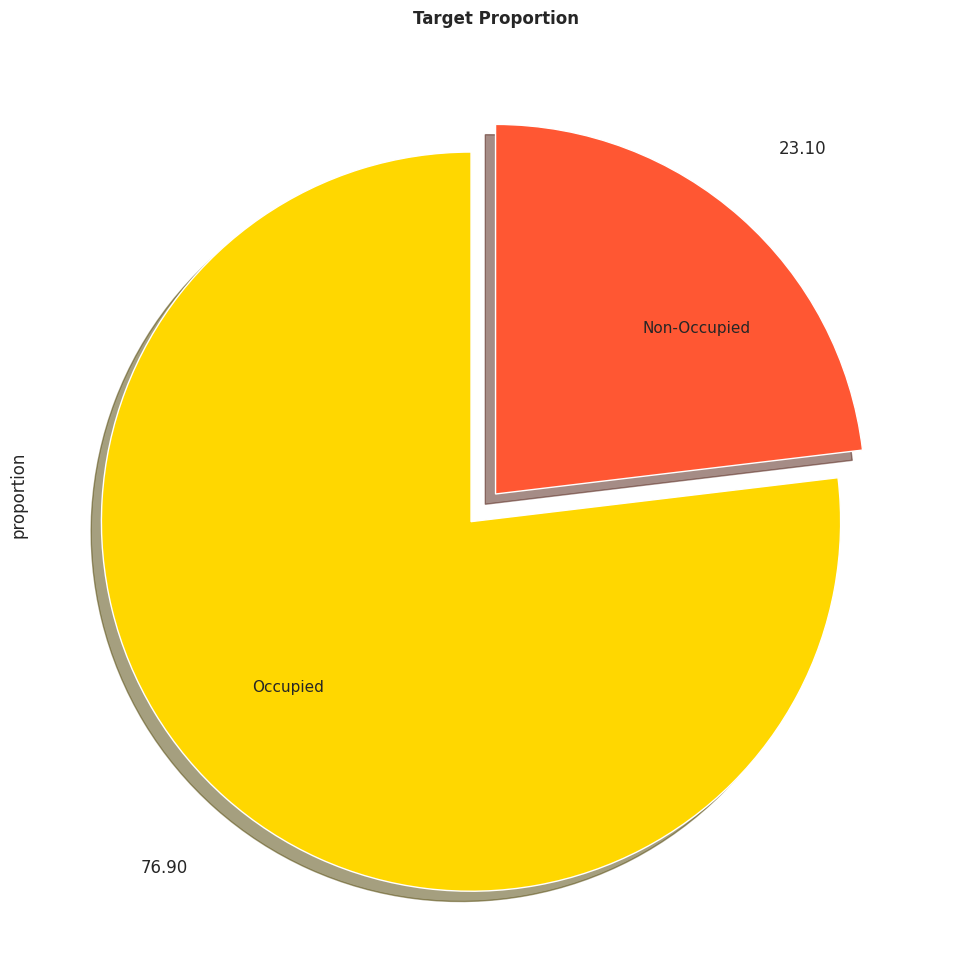

In [443]:
target_plot = y.value_counts(ascending=False, normalize=True)


# Customized Pie Chart
labels = ['Occupied', 'Non-Occupied']
target_plot.plot(kind='pie',  
                startangle=90, 
                shadow=True, 
                explode=(0.1, 0), 
                labels=labels, 
                pctdistance=1.25,
                labeldistance=.6, 
                autopct='%.2f',
                colors = ['#FFD700', '#FF5733']).set_title('Target Proportion', fontweight='bold')
plt.show()

# 6. Which evaluation metrics are most appropriate?**

In order to evaluate how the models perform, I'd go for F1 Score and ROC-AUC score. Due to the nature of the dataset that show us an important imbalance. F1 score combines precision and recall into a number, is really useful use this function in this matter because we need to identify false positive and false negative have a great impact and also highlight which model fails to detect one from another.

ROC-AUC is also a great candidate for this particular dataset that present an imbalance and shows how well the model ranks positives against negatives.


1.  **F1-score**

2.  **ROC-AUC**


In [444]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

# 7. How the values are distributed?

Humidity and Humidity Ratio appear to follow distributions that are closer to normal compared to the other variables. In contrast, CO₂ and Light are left-skewed, indicating a concentration of higher values with a longer tail toward lower values. Temperature is more centrally distributed, although it still shows a slight skew toward the lower end.

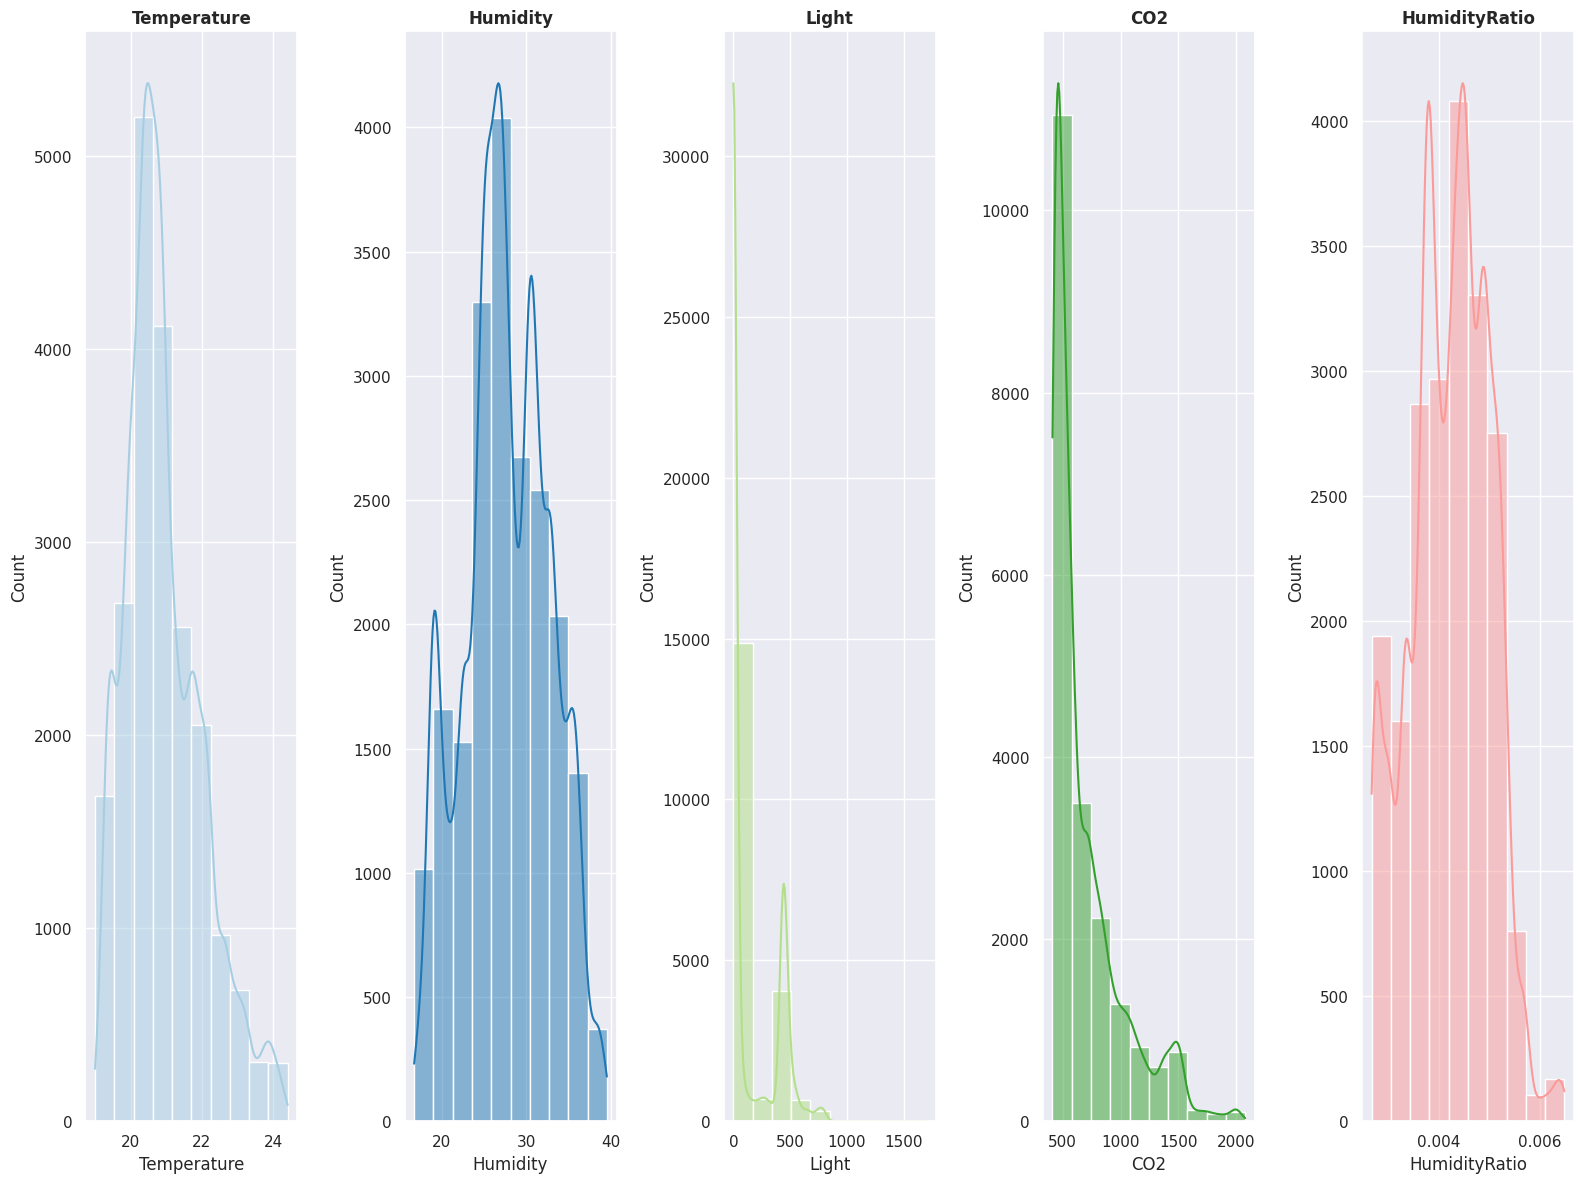

In [445]:
parameters = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']

list_colors = list(sns.color_palette("Paired", len(parameters)))


plt.figure(figsize=(16, 12))

for i, col in enumerate(parameters):
    plt.subplot(1, len(parameters), i + 1)  
    sns.histplot(X[col], bins=10, kde=True, color=list_colors[i])
    plt.title(col, fontweight='bold')

plt.tight_layout()
plt.show()

# 8. What preprocessing step are needed?

I first applied standardization using StandardScaler, which transforms the features by removing the mean and scaling them to unit variance. The standardized value (z-score) of a sample x is calculated as z=(x−μ)/σ.

After standardizing the data, I applied PCA to better understand the underlying structure and capture a more comprehensive view of the dataset. When using PCA, several important considerations must be taken into account. PCA can only be applied to numerical features, such as continuous variables or counts, and it is highly sensitive to the scale of the data. For this reason, standardization is typically an essential preprocessing step. Additionally, outliers can have a disproportionate impact on the resulting principal components, so it is important to assess and, if necessary, mitigate their influence before applying PCA.


In [446]:
X.columns

Index(['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio',
       'Day', 'WeekDay', 'Hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'humidity_smooth', 'humidity_ratio_smooth'],
      dtype='object')

In [447]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

X = X.drop(['date', 'WeekDay'], axis=1)

features = [
    'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio',
    'humidity_smooth', 'humidity_ratio_smooth',
    'Day', 'Hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

X = X.loc[:, features]

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# apply PCA
n_components = 3
pca = PCA(n_components=n_components)
X_pca_array = pca.fit_transform(X_scaled)

# keep the original X index so alignment works
component_names = [f"PC{i+1}" for i in range(X_pca_array.shape[1])]
X_pca = pd.DataFrame(X_pca_array, columns=component_names, index=X.index)

# align target FIRST, then fill missing values
y_aligned = y.loc[X_pca.index].fillna(0)

X_pca = X_pca.reset_index(drop=True)
y_aligned = y_aligned.reset_index(drop=True)

In [448]:
def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

In [449]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [450]:
X_pca.head()

,PC1,PC2,PC3
0,1.014582,3.428081,-0.075300
1,1.028728,3.430549,-0.074226
2,1.024991,3.434163,-0.073992
3,0.967611,3.258181,-0.147773
4,0.990712,3.262845,-0.148532


In [452]:
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix of loadings
    columns=component_names,  # The columns are the principal components
    index=X.columns,  # The rows are the original features
)
loadings.head()

,PC1,PC2,PC3
Temperature,0.082634,0.534335,0.031026
Humidity,0.422699,-0.204591,0.007423
Light,0.103419,0.483576,0.202649
CO2,0.259904,0.272946,0.190651
HumidityRatio,0.450302,-0.006344,0.018860


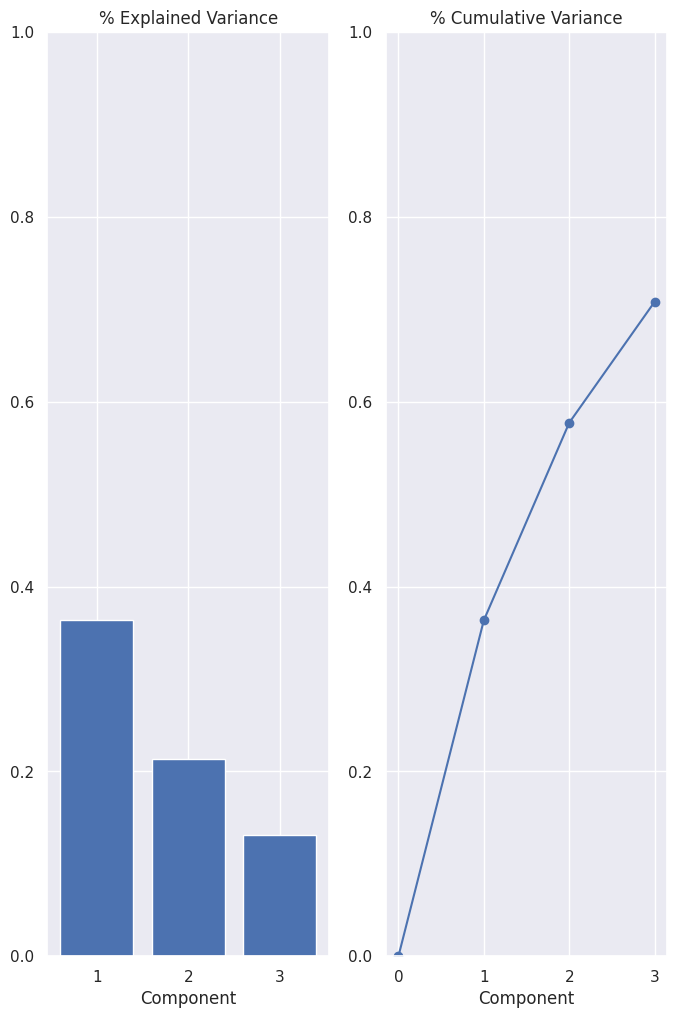

In [453]:
# Look at explained variance
plot_variance(pca);

In [454]:
mi_scores = make_mi_scores(X_pca, y_aligned, discrete_features=False)
mi_scores

PC2    0.351560
PC3    0.223267
PC1    0.094820
Name: MI Scores, dtype: float64

# 8. What models perform best on this dataset?
 
I plan to experiment with both Random Forest and Logistic Regression, and as an additional step, I will implement a cross-validation approach specifically designed for time series data to account for its temporal structure.
I chose Random Forest because it can automatically capture non-linear relationships, provides insights into feature importance, and often performs well without requiring extensive hyperparameter tuning.
Logistic Regression, on the other hand, is simple and highly interpretable, making it easy to understand how each feature influences the outcome. It also trains efficiently on large datasets and, in this case, is better suited to handling class imbalance.

# 9. Should date/time be used as a feature?

Yes, this dataset is based on human behavior patterns, which are inherently time-dependent. Therefore, time can be a relevant feature. However, models like RandomForest LogisticRegression and XGBoost do not interpret raw timestamps effectively. By transforming the timestamp into more meaningful features—such as day of the week, whether it is a weekend, and/or the month—we can provide more useful information to the model and potentially improve its performance.

In [455]:
X.head()

,Temperature,Humidity,Light,CO2,HumidityRatio,humidity_smooth,humidity_ratio_smooth,Day,Hour,hour_sin,hour_cos,dow_sin,dow_cos
8144,23.7000,26.272,585.200000,749.200000,0.004764,26.272000,0.004764,2,14,-0.5,-0.866025,0.0,1.0
8145,23.7180,26.290,578.400000,760.400000,0.004773,26.272590,0.004764,2,14,-0.5,-0.866025,0.0,1.0
8146,23.7300,26.230,572.666667,769.666667,0.004765,26.271194,0.004764,2,14,-0.5,-0.866025,0.0,1.0
8147,23.7225,26.125,493.750000,774.750000,0.004744,26.266401,0.004764,2,14,-0.5,-0.866025,0.0,1.0
8148,23.7540,26.200,488.600000,779.000000,0.004767,26.264223,0.004764,2,14,-0.5,-0.866025,0.0,1.0


In [456]:
print(len(X_pca) == len(y_aligned))
"""Same length!"""

True


'Same length!'

In [457]:
from sklearn.model_selection import TimeSeriesSplit

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb


tscv = TimeSeriesSplit(n_splits=5)

# Storing result to comparison later
roc_auc_score_result_rf = {}
roc_auc_score_result_lr = {}
roc_auc_score_result_xgb = {}


model_rfc = RandomForestClassifier()
model_lr = LogisticRegression()
model_xgb = xgb.XGBClassifier(tree_method="hist")

In [458]:
"""Time Series Cross Validation"""
for i, (train_index, valid_index) in enumerate(tscv.split(X_pca)):
    X_train, X_valid = X_pca.iloc[train_index], X_pca.iloc[valid_index]
    y_train, y_valid = y_aligned.loc[train_index], y_aligned.loc[valid_index]
    
    print("X_train:", X_train.shape, "X_valid:", X_valid.shape, sep='\n')
    print("y_train:", y_train.shape, "y_valid:", y_valid.shape, sep='\n')

    model_rfc.fit(X_train, y_train)
    model_lr.fit(X_train, y_train)
    model_xgb.fit(X_train, y_train)
    
    y_rfc = model_rfc.predict(X_valid)
    y_lr = model_lr.predict(X_valid)
    y_xgb = model_xgb.predict(X_valid)

    
    print(f"Random Forest Fold:{i} ROC AUC: {roc_auc_score(y_valid, y_rfc)}", sep='\n')
    print(f"LogisticRegression Fold:{i} ROC AUC: {roc_auc_score(y_valid, y_lr)}", sep='\n')
    print(f"XGBoost Classifier Fold:{i} ROC AUC: {roc_auc_score(y_valid, y_lr)}", sep='\n')
    
    roc_auc_score_result_rf[i] = roc_auc_score(y_valid, y_rfc)
    roc_auc_score_result_lr[i] = roc_auc_score(y_valid, y_lr)
    roc_auc_score_result_xgb[i] = roc_auc_score(y_valid, y_xgb)

X_train:
(3430, 3)
X_valid:
(3426, 3)
y_train:
(3430, 1)
y_valid:
(3426, 1)
Random Forest Fold:0 ROC AUC: 0.8011832536578299
LogisticRegression Fold:0 ROC AUC: 0.9076801390699696
XGBoost Classifier Fold:0 ROC AUC: 0.9076801390699696
X_train:
(6856, 3)
X_valid:
(3426, 3)
y_train:
(6856, 1)
y_valid:
(3426, 1)
Random Forest Fold:1 ROC AUC: 0.7391817023326651
LogisticRegression Fold:1 ROC AUC: 0.9597378277153559
XGBoost Classifier Fold:1 ROC AUC: 0.9597378277153559
X_train:
(10282, 3)
X_valid:
(3426, 3)
y_train:
(10282, 1)
y_valid:
(3426, 1)
Random Forest Fold:2 ROC AUC: 0.8078503536488015
LogisticRegression Fold:2 ROC AUC: 0.8996403178198153
XGBoost Classifier Fold:2 ROC AUC: 0.8996403178198153
X_train:
(13708, 3)
X_valid:
(3426, 3)
y_train:
(13708, 1)
y_valid:
(3426, 1)
Random Forest Fold:3 ROC AUC: 0.7212727272727273
LogisticRegression Fold:3 ROC AUC: 0.6324143356643357
XGBoost Classifier Fold:3 ROC AUC: 0.6324143356643357
X_train:
(17134, 3)
X_valid:
(3426, 3)
y_train:
(17134, 1)
y_val

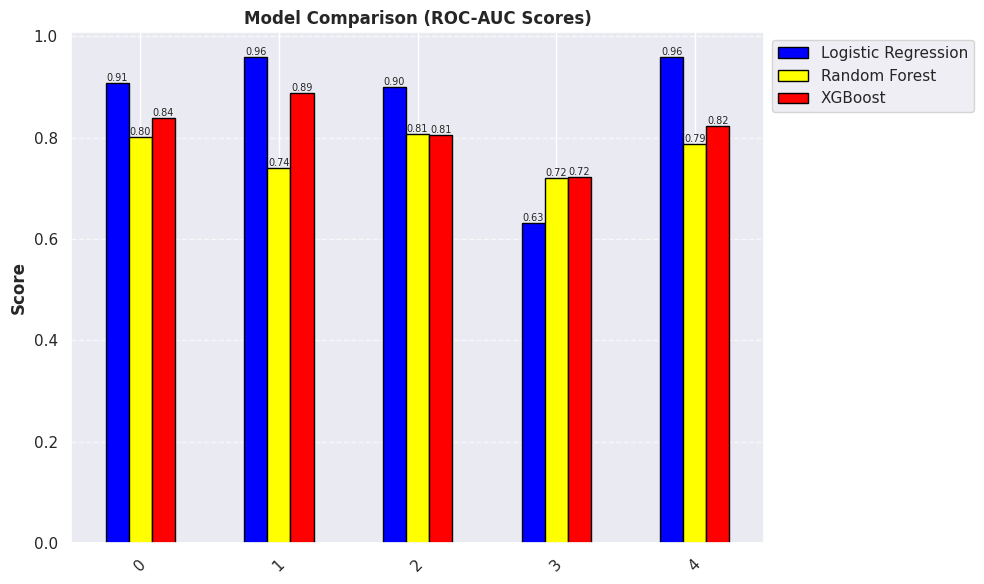

In [459]:
score_compare = pd.DataFrame({
    'Logistic Regression': roc_auc_score_result_lr,
    'Random Forest': roc_auc_score_result_rf,
    'XGBoost': roc_auc_score_result_xgb,
})

ax = score_compare.plot(kind='bar', figsize=(10, 6), edgecolor='black', color=['Blue','Yellow', 'Red'])

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=7)

plt.title('Model Comparison (ROC-AUC Scores)', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

* # 10. What model perform best on this dataset?

This plot compares the performance of three machine learning models—Logistic Regression, Random Forest, and XGBoost—using ROC-AUC scores across five different scenarios (0 to 4 on the x-axis). The ROC-AUC score measures how well each model distinguishes between classes, with values closer to 1 indicating better performance.
Logistic Regression performs best overall, achieving the highest scores in four out of the five scenarios. It reaches particularly strong results in scenarios 1 and 4, with scores around 0.96. This suggests that the data in most cases may follow relatively simple or linear patterns, which Logistic Regression can model effectively.
XGBoost shows consistently strong performance across all scenarios and is generally the second-best model. While it does not outperform Logistic Regression in most cases, it remains reliable and performs well even when the data becomes more complex.
Random Forest tends to perform the weakest among the three models, with lower scores and more variability. For example, its score drops noticeably in scenario 1 compared to the other models. Overall, the plot shows that while Logistic Regression is the strongest model in most cases, model performance varies depending on the data, highlighting the importance of testing multiple approaches.

* # 11. How would you detect overfitting?

Overfitting can be identified by comparing training and validation performance. A large gap where the model performs significantly better on the training data than on the validation data indicates overfitting. In this case, there is no clear evidence of such a discrepancy.

* # 12. What feature engineering could improve results?

During my exploratory data analysis (EDA), I applied the rolling() function to the Humidity and Humidity Ratio variables to smooth the data and improve visualization. This approach helped me better understand underlying trends, although further tuning of the lag window could enhance the results. Prior to applying the rolling function, I focused specifically on these two variables due to their high correlation. My goal was to assess whether rolling transformations could help reduce this correlation and reveal more independent patterns.

* # 13. What real-world issues could affect model reliability?

Sensor noise or failure is a major issue. Environmental sensors (e.g., CO₂, humidity, light) can drift over time, produce noisy readings, or fail entirely. For example, a faulty CO₂ sensor might falsely indicate occupancy when none exists, leading to incorrect predictions. Regular calibration and monitoring are essential to mitigate this. Changing lighting conditions can also impact performance. Models trained under controlled lighting may struggle when exposed to natural variations such as sunlight, shadows, or seasonal changes. For instance, a bright sunny day might mimic artificial lighting patterns associated with occupancy, confusing the model.